In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk torch ipywidgets joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.2 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import pickle
import joblib
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.optim as optim

import ipywidgets as widgets
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings("ignore")

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Semantic Search System E2E Deployment"

DATA_DIR = os.path.join(
    BASE_DIR,
    "data"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "outputs"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "results"
)

for directory in [
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    RESULT_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )

print("Project directories created.")
print(BASE_DIR)

Project directories created.
/content/drive/MyDrive/Semantic Search System E2E Deployment


In [ ]:
DATA_PATH = os.path.join(
    DATA_DIR,
    "/content/drive/MyDrive/Semantic Search System E2E Deployment/knowledge_base_improved 1.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (50000, 5)


,document_id,category,title,content,keywords
0,KB000001,Authentication,Unable to Access Your Login Password Step by Step,If you can no longer use your sign-in password...,"password recovery, reset password, identity ve..."
1,KB000002,Authentication,Login Troubleshooting the Easy Way,Problems with your log in are often caused by ...,"login not working, login error, technical issu..."
2,KB000003,Authentication,Setting Up Extra Login Step,You can set up your two-step verification your...,"set up two-factor authentication, enable two-f..."
3,KB000004,Authentication,Verification Code Troubleshooting Explained,Most issues with your login code clear up afte...,"verification code not working, verification co..."
4,KB000005,Authentication,How to Set Up Your Authentication App the Easy...,Setting up your authentication app takes only ...,"set up authenticator app, enable authenticator..."


In [ ]:
print("Dataset Shape")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape
Rows: 50000
Columns: 5

Columns:
['document_id', 'category', 'title', 'content', 'keywords']

Data Types:
document_id    object
category       object
title          object
content        object
keywords       object
dtype: object


In [ ]:
EXPECTED_COLUMNS = [
    "document_id",
    "category",
    "title",
    "content",
    "keywords"
]

missing_columns = [
    col
    for col in EXPECTED_COLUMNS
    if col not in df.columns
]

if len(missing_columns) == 0:

    print("All required columns are present.")

else:

    print("Missing columns:")
    print(missing_columns)

All required columns are present.


In [ ]:
print("Missing Values")
print("=" * 50)

display(
    df.isnull().sum()
)

Missing Values


,0
document_id,0
category,0
title,0
content,0
keywords,0


In [ ]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

Duplicate rows: 0


In [ ]:
print(
    "Number of categories:",
    df["category"].nunique()
)

display(
    df["category"].value_counts()
)

Number of categories: 15


,count
category,
Account Management,4143
Payments,3976
Authentication,3941
Orders,3839
Shipping,3690
General FAQ,3419
Technical Support,3250
Customer Support,3145
Subscriptions,3097


In [ ]:
df["content_length"] = (
    df["content"]
    .fillna("")
    .astype(str)
    .str.len()
)

display(
    df["content_length"].describe()
)

,content_length
count,50000.000000
mean,858.307060
std,105.762102
min,664.000000
25%,780.000000
50%,840.000000
75%,923.000000
max,1277.000000


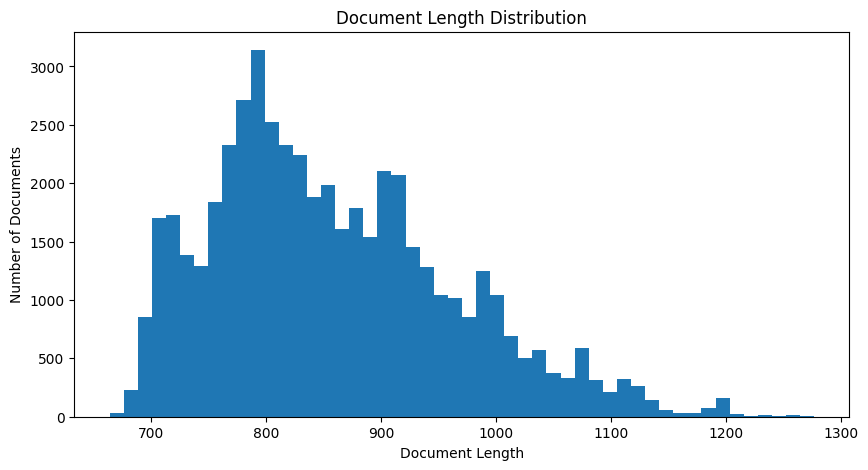

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["content_length"],
    bins=50
)

plt.xlabel("Document Length")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")

plt.show()

In [ ]:
stop_words = set(
    stopwords.words("english")
)

def preprocess_text(text):

    if pd.isna(text):
        return []

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Remove special characters
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return tokens

In [ ]:
for column in [
    "category",
    "title",
    "content",
    "keywords"
]:

    df[column] = (
        df[column]
        .fillna("")
        .astype(str)
    )

df["search_text"] = (
    df["title"] + " " +
    df["content"] + " " +
    df["keywords"]
)

display(
    df[
        [
            "document_id",
            "category",
            "title",
            "search_text"
        ]
    ].head()
)

,document_id,category,title,search_text
0,KB000001,Authentication,Unable to Access Your Login Password Step by Step,Unable to Access Your Login Password Step by S...
1,KB000002,Authentication,Login Troubleshooting the Easy Way,Login Troubleshooting the Easy Way Problems wi...
2,KB000003,Authentication,Setting Up Extra Login Step,Setting Up Extra Login Step You can set up you...
3,KB000004,Authentication,Verification Code Troubleshooting Explained,Verification Code Troubleshooting Explained Mo...
4,KB000005,Authentication,How to Set Up Your Authentication App the Easy...,How to Set Up Your Authentication App the Easy...


In [ ]:
df["tokens"] = (
    df["search_text"]
    .apply(preprocess_text)
)

display(
    df[
        [
            "document_id",
            "title",
            "tokens"
        ]
    ].head()
)

,document_id,title,tokens
0,KB000001,Unable to Access Your Login Password Step by Step,"[unable, access, login, password, step, step, ..."
1,KB000002,Login Troubleshooting the Easy Way,"[login, troubleshooting, easy, way, problems, ..."
2,KB000003,Setting Up Extra Login Step,"[setting, extra, login, step, set, two, step, ..."
3,KB000004,Verification Code Troubleshooting Explained,"[verification, code, troubleshooting, explaine..."
4,KB000005,How to Set Up Your Authentication App the Easy...,"[set, authentication, app, easy, way, setting,..."


In [ ]:
before = len(df)

df = df[
    df["tokens"].apply(len) > 0
].reset_index(drop=True)

after = len(df)

print("Before:", before)
print("After:", after)
print("Removed:", before - after)

Before: 50000
After: 50000
Removed: 0


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(
    "Training documents:",
    len(train_df)
)

print(
    "Testing documents:",
    len(test_df)
)

Training documents: 40000
Testing documents: 10000


In [ ]:
training_sentences = (
    train_df["tokens"].tolist()
)

word_counts = Counter()

for sentence in training_sentences:

    word_counts.update(sentence)

MIN_COUNT = 2

vocab_words = [
    word
    for word, count in word_counts.items()
    if count >= MIN_COUNT
]

word_to_idx = {
    word: idx
    for idx, word in enumerate(vocab_words)
}

idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

VOCAB_SIZE = len(word_to_idx)

print("Unique words:", len(word_counts))
print("Vocabulary size:", VOCAB_SIZE)

Unique words: 733
Vocabulary size: 733


In [ ]:
WINDOW_SIZE = 2

training_pairs = []

for sentence in training_sentences:

    sentence_ids = [
        word_to_idx[word]
        for word in sentence
        if word in word_to_idx
    ]

    for center_position in range(
        len(sentence_ids)
    ):

        center_word = sentence_ids[
            center_position
        ]

        start = max(
            0,
            center_position - WINDOW_SIZE
        )

        end = min(
            len(sentence_ids),
            center_position + WINDOW_SIZE + 1
        )

        for context_position in range(
            start,
            end
        ):

            if (
                context_position ==
                center_position
            ):
                continue

            context_word = sentence_ids[
                context_position
            ]

            training_pairs.append(
                (
                    center_word,
                    context_word
                )
            )

print(
    "Training pairs:",
    len(training_pairs)
)

Training pairs: 15829408


In [ ]:
class Word2VecSkipGram(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim
    ):

        super().__init__()

        self.input_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.output_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        nn.init.uniform_(
            self.input_embeddings.weight,
            -0.5,
            0.5
        )

        nn.init.zeros_(
            self.output_embeddings.weight
        )

    def forward(
        self,
        center_words,
        context_words
    ):

        center_vectors = (
            self.input_embeddings(
                center_words
            )
        )

        context_vectors = (
            self.output_embeddings(
                context_words
            )
        )

        scores = torch.sum(
            center_vectors *
            context_vectors,
            dim=1
        )

        return scores

In [ ]:
EMBEDDING_DIM = 100
LEARNING_RATE = 0.003
EPOCHS = 5
NEGATIVE_SAMPLES = 5
BATCH_SIZE = 512

word2vec_model = Word2VecSkipGram(
    VOCAB_SIZE,
    EMBEDDING_DIM
).to(device)

optimizer = optim.Adam(
    word2vec_model.parameters(),
    lr=LEARNING_RATE
)

loss_function = nn.BCEWithLogitsLoss()

negative_distribution = np.array([
    word_counts[
        idx_to_word[i]
    ] ** 0.75
    for i in range(VOCAB_SIZE)
])

negative_distribution = (
    negative_distribution /
    negative_distribution.sum()
)

training_pairs_array = np.array(
    training_pairs,
    dtype=np.int64
)

num_pairs = len(
    training_pairs_array
)

print("Word2Vec training started...")

Word2Vec training started...


In [ ]:
for epoch in range(EPOCHS):

    np.random.shuffle(
        training_pairs_array
    )

    total_loss = 0

    number_of_batches = math.ceil(
        num_pairs / BATCH_SIZE
    )

    for start in range(
        0,
        num_pairs,
        BATCH_SIZE
    ):

        batch = training_pairs_array[
            start:start + BATCH_SIZE
        ]

        center_words = torch.tensor(
            batch[:, 0],
            dtype=torch.long,
            device=device
        )

        positive_words = torch.tensor(
            batch[:, 1],
            dtype=torch.long,
            device=device
        )

        current_batch_size = len(batch)

        negative_words = np.random.choice(
            VOCAB_SIZE,
            size=(
                current_batch_size,
                NEGATIVE_SAMPLES
            ),
            p=negative_distribution
        )

        negative_words = torch.tensor(
            negative_words,
            dtype=torch.long,
            device=device
        )

        optimizer.zero_grad()

        # Positive examples
        positive_scores = word2vec_model(
            center_words,
            positive_words
        )

        positive_labels = torch.ones(
            current_batch_size,
            device=device
        )

        positive_loss = loss_function(
            positive_scores,
            positive_labels
        )

        # Negative examples
        center_vectors = (
            word2vec_model
            .input_embeddings(
                center_words
            )
        )

        negative_vectors = (
            word2vec_model
            .output_embeddings(
                negative_words
            )
        )

        negative_scores = torch.bmm(
            negative_vectors,
            center_vectors.unsqueeze(2)
        ).squeeze(2)

        negative_labels = torch.zeros(
            current_batch_size,
            NEGATIVE_SAMPLES,
            device=device
        )

        negative_loss = loss_function(
            negative_scores,
            negative_labels
        )

        loss = (
            positive_loss +
            negative_loss
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        number_of_batches
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )

print("Word2Vec training completed.")

Epoch 1/5 - Loss: 0.4860
Epoch 2/5 - Loss: 0.4710
Epoch 3/5 - Loss: 0.4701
Epoch 4/5 - Loss: 0.4701
Epoch 5/5 - Loss: 0.4699
Word2Vec training completed.


In [ ]:
MIN_NGRAM = 3
MAX_NGRAM = 6

def generate_ngrams(
    word,
    min_n=MIN_NGRAM,
    max_n=MAX_NGRAM
):

    word = "<" + word + ">"

    ngrams = []

    for n in range(
        min_n,
        max_n + 1
    ):

        for i in range(
            len(word) - n + 1
        ):

            ngram = word[
                i:i+n
            ]

            ngrams.append(
                ngram
            )

    return ngrams

In [ ]:
test_word = "machine"

print(
    generate_ngrams(test_word)
)

['<ma', 'mac', 'ach', 'chi', 'hin', 'ine', 'ne>', '<mac', 'mach', 'achi', 'chin', 'hine', 'ine>', '<mach', 'machi', 'achin', 'chine', 'hine>', '<machi', 'machin', 'achine', 'chine>']


In [ ]:
ngram_counter = Counter()

for word in vocab_words:

    ngrams = generate_ngrams(word)

    ngram_counter.update(
        ngrams
    )

ngram_to_idx = {
    ngram: idx
    for idx, ngram
    in enumerate(ngram_counter.keys())
}

idx_to_ngram = {
    idx: ngram
    for ngram, idx
    in ngram_to_idx.items()
}

NGRAM_VOCAB_SIZE = len(
    ngram_to_idx
)

print(
    "Character n-gram vocabulary:",
    NGRAM_VOCAB_SIZE
)

Character n-gram vocabulary: 8441


In [ ]:
word_ngram_ids = {}

for word in vocab_words:

    ids = []

    for ngram in generate_ngrams(word):

        if ngram in ngram_to_idx:

            ids.append(
                ngram_to_idx[ngram]
            )

    word_ngram_ids[
        word_to_idx[word]
    ] = ids

print(
    "Example word:",
    vocab_words[0]
)

print(
    "N-gram IDs:",
    word_ngram_ids[
        word_to_idx[vocab_words[0]]
    ][:10]
)

Example word: monitor
N-gram IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
class FastTextSkipGram(nn.Module):

    def __init__(
        self,
        vocab_size,
        ngram_vocab_size,
        embedding_dim
    ):

        super().__init__()

        self.word_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.ngram_embeddings = nn.Embedding(
            ngram_vocab_size,
            embedding_dim
        )

        self.output_embeddings = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        nn.init.uniform_(
            self.word_embeddings.weight,
            -0.5,
            0.5
        )

        nn.init.uniform_(
            self.ngram_embeddings.weight,
            -0.5,
            0.5
        )

        nn.init.zeros_(
            self.output_embeddings.weight
        )

    def get_center_vectors(
        self,
        word_ids,
        word_ngram_matrix
    ):

        word_vectors = (
            self.word_embeddings(
                word_ids
            )
        )

        ngram_vectors = (
            self.ngram_embeddings(
                word_ngram_matrix
            )
        )

        # Padding ID -1 is handled outside
        mask = (
            word_ngram_matrix != -1
        ).float()

        mask = mask.unsqueeze(-1)

        ngram_vectors = (
            ngram_vectors * mask
        )

        ngram_sum = (
            ngram_vectors.sum(dim=1)
        )

        ngram_count = (
            mask.sum(dim=1)
            .clamp(min=1)
        )

        ngram_mean = (
            ngram_sum /
            ngram_count
        )

        return (
            word_vectors +
            ngram_mean
        )

    def forward(
        self,
        center_words,
        center_ngram_ids,
        context_words
    ):

        center_vectors = (
            self.get_center_vectors(
                center_words,
                center_ngram_ids
            )
        )

        context_vectors = (
            self.output_embeddings(
                context_words
            )
        )

        scores = torch.sum(
            center_vectors *
            context_vectors,
            dim=1
        )

        return scores

In [ ]:
MAX_NGRAMS_PER_WORD = max(
    len(ids)
    for ids in word_ngram_ids.values()
)

ngram_matrix = np.full(
    (
        VOCAB_SIZE,
        MAX_NGRAMS_PER_WORD
    ),
    -1,
    dtype=np.int64
)

for word_id, ids in word_ngram_ids.items():

    ngram_matrix[
        word_id,
        :len(ids)
    ] = ids

print(
    "N-gram matrix shape:",
    ngram_matrix.shape
)

N-gram matrix shape: (733, 54)


In [ ]:
fasttext_model = FastTextSkipGram(
    VOCAB_SIZE,
    NGRAM_VOCAB_SIZE,
    EMBEDDING_DIM
).to(device)

optimizer_ft = optim.Adam(
    fasttext_model.parameters(),
    lr=LEARNING_RATE
)

print("FastText model created.")

FastText model created.


In [ ]:
ngram_matrix_tensor = torch.tensor(
    ngram_matrix,
    dtype=torch.long
)

# Replace padding -1 with 0 temporarily.
# The mask still remembers which positions are padding.
ngram_matrix_tensor_safe = (
    ngram_matrix_tensor
    .clone()
)

ngram_matrix_tensor_safe[
    ngram_matrix_tensor_safe == -1
] = 0

ngram_matrix_tensor_safe = (
    ngram_matrix_tensor_safe.to(device)
)

print(
    ngram_matrix_tensor_safe.shape
)

torch.Size([733, 54])


In [ ]:
print("FastText training started...")

for epoch in range(EPOCHS):

    np.random.shuffle(
        training_pairs_array
    )

    total_loss = 0

    number_of_batches = math.ceil(
        num_pairs / BATCH_SIZE
    )

    for start in range(
        0,
        num_pairs,
        BATCH_SIZE
    ):

        batch = training_pairs_array[
            start:start + BATCH_SIZE
        ]

        center_words = torch.tensor(
            batch[:, 0],
            dtype=torch.long,
            device=device
        )

        positive_words = torch.tensor(
            batch[:, 1],
            dtype=torch.long,
            device=device
        )

        current_batch_size = len(batch)

        center_ngram_ids = (
            ngram_matrix_tensor_safe[
                center_words
            ]
        )

        negative_words = np.random.choice(
            VOCAB_SIZE,
            size=(
                current_batch_size,
                NEGATIVE_SAMPLES
            ),
            p=negative_distribution
        )

        negative_words = torch.tensor(
            negative_words,
            dtype=torch.long,
            device=device
        )

        optimizer_ft.zero_grad()

        # Positive samples
        positive_scores = fasttext_model(
            center_words,
            center_ngram_ids,
            positive_words
        )

        positive_labels = torch.ones(
            current_batch_size,
            device=device
        )

        positive_loss = loss_function(
            positive_scores,
            positive_labels
        )

        # Negative samples
        center_vectors = (
            fasttext_model.get_center_vectors(
                center_words,
                center_ngram_ids
            )
        )

        negative_vectors = (
            fasttext_model
            .output_embeddings(
                negative_words
            )
        )

        negative_scores = torch.bmm(
            negative_vectors,
            center_vectors.unsqueeze(2)
        ).squeeze(2)

        negative_labels = torch.zeros(
            current_batch_size,
            NEGATIVE_SAMPLES,
            device=device
        )

        negative_loss = loss_function(
            negative_scores,
            negative_labels
        )

        loss = (
            positive_loss +
            negative_loss
        )

        loss.backward()

        optimizer_ft.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        number_of_batches
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )

print("FastText training completed.")

FastText training started...
Epoch 1/5 - Loss: 0.4862
Epoch 2/5 - Loss: 0.4732
Epoch 3/5 - Loss: 0.4726
Epoch 4/5 - Loss: 0.4723
Epoch 5/5 - Loss: 0.4721
FastText training completed.


In [ ]:
word2vec_embeddings = (
    word2vec_model
    .input_embeddings
    .weight
    .detach()
    .cpu()
    .numpy()
)

print(
    "Word2Vec embedding matrix:",
    word2vec_embeddings.shape
)

Word2Vec embedding matrix: (733, 100)


In [35]:
def get_word2vec_document_vector(
    tokens
):

    vectors = []

    for word in tokens:

        if word in word_to_idx:

            idx = word_to_idx[word]

            vectors.append(
                word2vec_embeddings[idx]
            )

    if len(vectors) == 0:

        return np.zeros(
            EMBEDDING_DIM,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    )

In [36]:
fasttext_word_embeddings = (
    fasttext_model
    .word_embeddings
    .weight
    .detach()
    .cpu()
    .numpy()
)

fasttext_ngram_embeddings = (
    fasttext_model
    .ngram_embeddings
    .weight
    .detach()
    .cpu()
    .numpy()
)

In [37]:
def get_fasttext_word_vector(
    word
):

    vectors = []

    # Known word vector
    if word in word_to_idx:

        word_id = word_to_idx[word]

        vectors.append(
            fasttext_word_embeddings[
                word_id
            ]
        )

    # Character n-gram vectors
    ngrams = generate_ngrams(word)

    for ngram in ngrams:

        if ngram in ngram_to_idx:

            ngram_id = (
                ngram_to_idx[ngram]
            )

            vectors.append(
                fasttext_ngram_embeddings[
                    ngram_id
                ]
            )

    if len(vectors) == 0:

        return np.zeros(
            EMBEDDING_DIM,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    )

In [38]:
def get_fasttext_document_vector(
    tokens
):

    vectors = []

    for word in tokens:

        vector = get_fasttext_word_vector(
            word
        )

        if np.linalg.norm(vector) > 0:

            vectors.append(vector)

    if len(vectors) == 0:

        return np.zeros(
            EMBEDDING_DIM,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    )

In [39]:
print("Creating Word2Vec document vectors...")

train_df["word2vec_vector"] = (
    train_df["tokens"]
    .apply(
        get_word2vec_document_vector
    )
)

test_df["word2vec_vector"] = (
    test_df["tokens"]
    .apply(
        get_word2vec_document_vector
    )
)

print("Word2Vec document vectors created.")

Creating Word2Vec document vectors...
Word2Vec document vectors created.


In [40]:
print("Creating FastText document vectors...")

train_df["fasttext_vector"] = (
    train_df["tokens"]
    .apply(
        get_fasttext_document_vector
    )
)

test_df["fasttext_vector"] = (
    test_df["tokens"]
    .apply(
        get_fasttext_document_vector
    )
)

print("FastText document vectors created.")

Creating FastText document vectors...
FastText document vectors created.


In [41]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20000
)

train_tfidf = (
    tfidf_vectorizer.fit_transform(
        train_df["search_text"]
    )
)

test_tfidf = (
    tfidf_vectorizer.transform(
        test_df["search_text"]
    )
)

print(
    "Training TF-IDF:",
    train_tfidf.shape
)

print(
    "Testing TF-IDF:",
    test_tfidf.shape
)

Training TF-IDF: (40000, 695)
Testing TF-IDF: (10000, 695)


In [42]:
def cosine_similarity_score(
    query_vector,
    document_vector
):

    query_norm = np.linalg.norm(
        query_vector
    )

    document_norm = np.linalg.norm(
        document_vector
    )

    if (
        query_norm == 0 or
        document_norm == 0
    ):

        return 0.0

    return np.dot(
        query_vector,
        document_vector
    ) / (
        query_norm *
        document_norm
    )

In [43]:
def get_word2vec_query_vector(
    query
):

    tokens = preprocess_text(
        query
    )

    return get_word2vec_document_vector(
        tokens
    )

In [44]:
def get_fasttext_query_vector(
    query
):

    tokens = preprocess_text(
        query
    )

    return get_fasttext_document_vector(
        tokens
    )

In [45]:
def word2vec_search(
    query,
    documents_df,
    top_k=5
):

    query_vector = (
        get_word2vec_query_vector(
            query
        )
    )

    results = documents_df.copy()

    results["similarity_score"] = (
        results["word2vec_vector"]
        .apply(
            lambda vector:
            cosine_similarity_score(
                query_vector,
                vector
            )
        )
    )

    results = results.sort_values(
        "similarity_score",
        ascending=False
    )

    return results.head(
        top_k
    )[
        [
            "document_id",
            "category",
            "title",
            "similarity_score"
        ]
    ].reset_index(drop=True)

In [46]:
def fasttext_search(
    query,
    documents_df,
    top_k=5
):

    query_vector = (
        get_fasttext_query_vector(
            query
        )
    )

    results = documents_df.copy()

    results["similarity_score"] = (
        results["fasttext_vector"]
        .apply(
            lambda vector:
            cosine_similarity_score(
                query_vector,
                vector
            )
        )
    )

    results = results.sort_values(
        "similarity_score",
        ascending=False
    )

    return results.head(
        top_k
    )[
        [
            "document_id",
            "category",
            "title",
            "similarity_score"
        ]
    ].reset_index(drop=True)

In [47]:
def tfidf_search(
    query,
    documents_df,
    tfidf_matrix,
    top_k=5
):

    query_vector = (
        tfidf_vectorizer.transform(
            [query]
        )
    )

    scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    top_indices = np.argsort(
        scores
    )[::-1][:top_k]

    results = documents_df.iloc[
        top_indices
    ].copy()

    results["similarity_score"] = (
        scores[top_indices]
    )

    return results[
        [
            "document_id",
            "category",
            "title",
            "similarity_score"
        ]
    ].reset_index(drop=True)

In [48]:
def search(
    query,
    model="FastText",
    top_k=5
):

    if not query.strip():

        raise ValueError(
            "Please enter a search query."
        )

    if model == "Word2Vec":

        return word2vec_search(
            query,
            test_df,
            top_k
        )

    elif model == "FastText":

        return fasttext_search(
            query,
            test_df,
            top_k
        )

    elif model == "TF-IDF":

        return tfidf_search(
            query,
            test_df,
            test_tfidf,
            top_k
        )

    else:

        raise ValueError(
            "Invalid model selected."
        )

In [49]:
query = "artificial intelligence and machine learning"

for model in [
    "Word2Vec",
    "FastText",
    "TF-IDF"
]:

    print("\n")
    print("=" * 80)
    print(model)
    print("=" * 80)

    results = search(
        query,
        model=model,
        top_k=5
    )

    display(results)



Word2Vec


,document_id,category,title,similarity_score
0,KB005858,Account Management,Enable Group Account on Your Account on iOS,0.0
1,KB033554,General FAQ,Viewing Your Warranty on iOS,0.0
2,KB009428,Orders,Troubleshoot Your Confirmation Email Step by Step,0.0
3,KB000200,Authentication,Edit Your Login Email,0.0
4,KB012448,Shipping,How to Set Up Your Express Delivery,0.0




FastText


,document_id,category,title,similarity_score
0,KB021123,Security,Read Your Security Warning at a Glance for Bus...,0.506367
1,KB021843,Security,Understanding Your Security Warning in the App,0.493422
2,KB043474,Security,Track Your Account Alert in the App,0.490768
3,KB022239,Security,Track Your Security Alert for New Users,0.487446
4,KB042886,Security,Checking Security Warning Status on iOS,0.480990




TF-IDF


,document_id,category,title,similarity_score
0,KB033554,General FAQ,Viewing Your Warranty on iOS,0.0
1,KB005858,Account Management,Enable Group Account on Your Account on iOS,0.0
2,KB015201,Refunds,Add a New Refund,0.0
3,KB018708,Profile Settings,Modify Your Contact Details on Android,0.0
4,KB025080,Technical Support,Resolving No Sound Issues in the App,0.0


In [51]:
model_dropdown = widgets.Dropdown(
    options=[
        "Word2Vec",
        "FastText",
        "TF-IDF"
    ],
    value="FastText",
    description="Model:"
)

query_box = widgets.Text(
    value="",
    placeholder="Enter your search query",
    description="Query:",
    layout=widgets.Layout(
        width="80%"
    )
)

top_k_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=20,
    step=1,
    description="Top-K:",
    continuous_update=False
)

search_button = widgets.Button(
    description="Search",
    button_style="primary"
)

output = widgets.Output()

In [52]:
def on_search_button_clicked(
    button
):

    with output:

        clear_output()

        query = query_box.value
        model = model_dropdown.value
        top_k = top_k_slider.value

        if not query.strip():

            print(
                "Please enter a search query."
            )

            return

        print("=" * 80)
        print("SEMANTIC SEARCH SYSTEM")
        print("=" * 80)

        print(
            "Selected Model:",
            model
        )

        print(
            "Query:",
            query
        )

        print(
            "Top-K:",
            top_k
        )

        print("=" * 80)

        results = search(
            query,
            model=model,
            top_k=top_k
        )

        display(results)


search_button.on_click(
    on_search_button_clicked
)

In [53]:
display(
    model_dropdown,
    query_box,
    top_k_slider,
    search_button,
    output
)

Dropdown(description='Model:', index=1, options=('Word2Vec', 'FastText', 'TF-IDF'), value='FastText')

Text(value='', description='Query:', layout=Layout(width='80%'), placeholder='Enter your search query')

IntSlider(value=5, continuous_update=False, description='Top-K:', max=20, min=1)

Button(button_style='primary', description='Search', style=ButtonStyle())

Output()

In [54]:
def analyze_oov_query(
    query
):

    tokens = preprocess_text(
        query
    )

    known = []
    unseen = []

    for word in tokens:

        if word in word_to_idx:

            known.append(word)

        else:

            unseen.append(word)

    return {
        "tokens": tokens,
        "known_words": known,
        "unseen_words": unseen
    }

In [55]:
oov_query = (
    "quantumcomputing neuralarchitecture"
)

oov_analysis = analyze_oov_query(
    oov_query
)

print(
    "Query:",
    oov_query
)

print(
    "\nTokens:",
    oov_analysis["tokens"]
)

print(
    "\nKnown words:",
    oov_analysis["known_words"]
)

print(
    "\nUnseen words:",
    oov_analysis["unseen_words"]
)

Query: quantumcomputing neuralarchitecture

Tokens: ['quantumcomputing', 'neuralarchitecture']

Known words: []

Unseen words: ['quantumcomputing', 'neuralarchitecture']


In [56]:
oov_query = (
    "quantumcomputing neuralarchitecture"
)

print("WORD2VEC")
print("=" * 60)

word2vec_oov_vector = (
    get_word2vec_query_vector(
        oov_query
    )
)

print(
    "Vector norm:",
    np.linalg.norm(
        word2vec_oov_vector
    )
)

print("\nFASTTEXT")
print("=" * 60)

fasttext_oov_vector = (
    get_fasttext_query_vector(
        oov_query
    )
)

print(
    "Vector norm:",
    np.linalg.norm(
        fasttext_oov_vector
    )
)

WORD2VEC
Vector norm: 0.0

FASTTEXT
Vector norm: 1.8597158


In [57]:
evaluation_queries = []

for _, row in test_df.iterrows():

    query = row["title"]

    category = row["category"]

    document_id = row["document_id"]

    if str(query).strip():

        evaluation_queries.append({
            "query": query,
            "category": category,
            "document_id": document_id
        })

evaluation_queries = pd.DataFrame(
    evaluation_queries
)

print(
    "Evaluation queries:",
    len(evaluation_queries)
)

display(
    evaluation_queries.head()
)

Evaluation queries: 10000


,query,category,document_id
0,Viewing Your Warranty on iOS,General FAQ,KB033554
1,Troubleshoot Your Confirmation Email Step by Step,Orders,KB009428
2,Edit Your Login Email,Authentication,KB000200
3,How to Set Up Your Express Delivery,Shipping,KB012448
4,Broken On Arrival Stopped Working,Shipping,KB039490


In [58]:
def precision_at_k(
    result_categories,
    true_category,
    k
):

    top_categories = (
        result_categories[:k]
    )

    if len(top_categories) == 0:

        return 0.0

    relevant = sum(
        category == true_category
        for category
        in top_categories
    )

    return (
        relevant /
        len(top_categories)
    )

In [59]:
def recall_at_k(
    result_categories,
    true_category,
    total_relevant,
    k
):

    top_categories = (
        result_categories[:k]
    )

    relevant_retrieved = sum(
        category == true_category
        for category
        in top_categories
    )

    if total_relevant == 0:

        return 0.0

    return (
        relevant_retrieved /
        total_relevant
    )

In [60]:
def reciprocal_rank(
    result_categories,
    true_category
):

    for rank, category in enumerate(
        result_categories,
        start=1
    ):

        if category == true_category:

            return 1.0 / rank

    return 0.0

In [61]:
def ndcg_at_k(
    result_categories,
    true_category,
    k
):

    relevances = [
        1 if category == true_category
        else 0
        for category
        in result_categories[:k]
    ]

    if len(relevances) == 0:

        return 0.0

    dcg = 0.0

    for i, relevance in enumerate(
        relevances
    ):

        dcg += (
            relevance /
            np.log2(i + 2)
        )

    total_relevant = sum(
        1
        for category
        in result_categories
        if category == true_category
    )

    ideal_relevances = [
        1
    ] * min(
        total_relevant,
        k
    )

    idcg = 0.0

    for i, relevance in enumerate(
        ideal_relevances
    ):

        idcg += (
            relevance /
            np.log2(i + 2)
        )

    if idcg == 0:

        return 0.0

    return dcg / idcg

In [62]:
def evaluate_model(
    model_name,
    k=5,
    max_queries=100
):

    metrics = []

    queries_to_test = (
        evaluation_queries
        .head(max_queries)
    )

    for _, row in queries_to_test.iterrows():

        query = row["query"]

        true_category = row[
            "category"
        ]

        results = search(
            query,
            model=model_name,
            top_k=k
        )

        result_categories = (
            results["category"]
            .tolist()
        )

        total_relevant = (
            test_df["category"]
            .eq(true_category)
            .sum()
        )

        precision = precision_at_k(
            result_categories,
            true_category,
            k
        )

        recall = recall_at_k(
            result_categories,
            true_category,
            total_relevant,
            k
        )

        mrr = reciprocal_rank(
            result_categories,
            true_category
        )

        ndcg = ndcg_at_k(
            result_categories,
            true_category,
            k
        )

        metrics.append({
            "precision@k": precision,
            "recall@k": recall,
            "MRR": mrr,
            "nDCG@k": ndcg
        })

    metrics_df = pd.DataFrame(
        metrics
    )

    return metrics_df.mean()

In [63]:
K = 5

model_metrics = []

for model_name in [
    "Word2Vec",
    "FastText",
    "TF-IDF"
]:

    print(
        f"Evaluating {model_name}..."
    )

    metrics = evaluate_model(
        model_name,
        k=K,
        max_queries=100
    )

    model_metrics.append({
        "Model": model_name,
        "Precision@5": metrics[
            "precision@k"
        ],
        "Recall@5": metrics[
            "recall@k"
        ],
        "MRR": metrics[
            "MRR"
        ],
        "nDCG@5": metrics[
            "nDCG@k"
        ]
    })

comparison_df = pd.DataFrame(
    model_metrics
)

comparison_df

Evaluating Word2Vec...
Evaluating FastText...
Evaluating TF-IDF...


,Model,Precision@5,Recall@5,MRR,nDCG@5
0,Word2Vec,0.896,0.006758,0.929167,0.932622
1,FastText,0.864,0.006491,0.882833,0.895542
2,TF-IDF,0.902,0.006779,0.936667,0.939558


In [64]:
best_model = comparison_df.loc[
    comparison_df["nDCG@5"].idxmax(),
    "Model"
]

print(
    "Best retrieval model based on nDCG@5:"
)

print(
    best_model
)

Best retrieval model based on nDCG@5:
TF-IDF


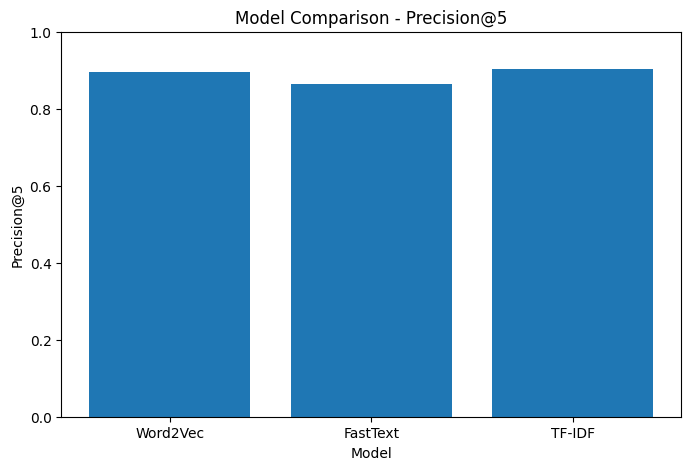

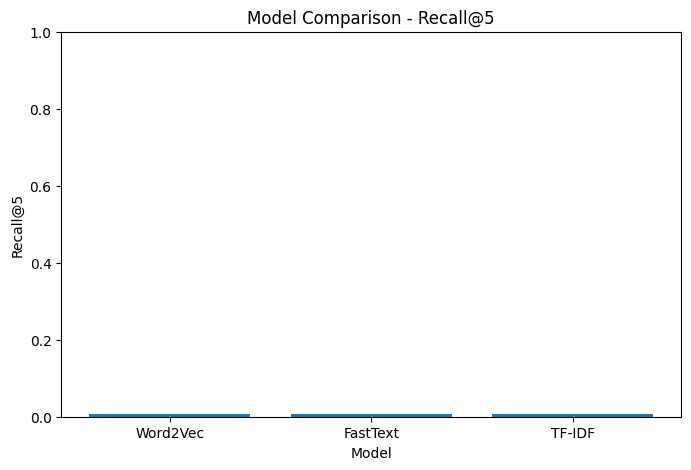

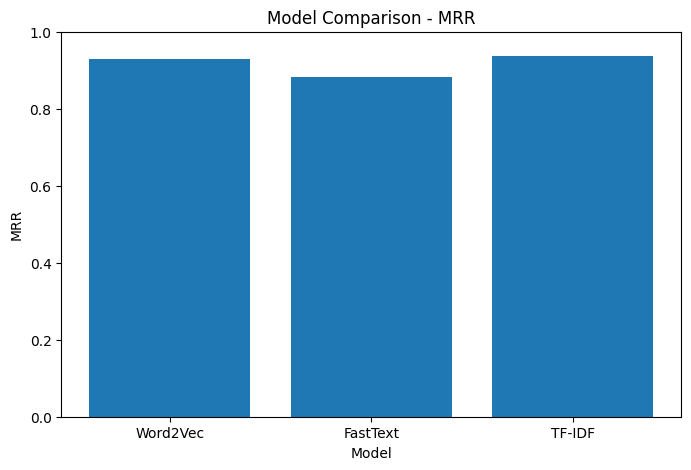

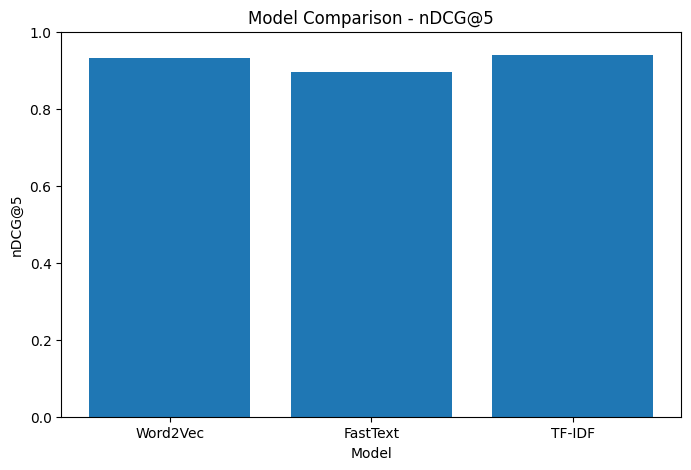

In [65]:
metrics_to_plot = [
    "Precision@5",
    "Recall@5",
    "MRR",
    "nDCG@5"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison_df["Model"],
        comparison_df[metric]
    )

    plt.title(
        f"Model Comparison - {metric}"
    )

    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.ylim(0, 1)

    plt.show()

In [66]:
def compare_models(
    query,
    top_k=5
):

    all_results = {}

    for model_name in [
        "Word2Vec",
        "FastText",
        "TF-IDF"
    ]:

        results = search(
            query,
            model=model_name,
            top_k=top_k
        )

        all_results[
            model_name
        ] = results

    return all_results

In [67]:
query = "machine learning applications"

results = compare_models(
    query,
    top_k=5
)

for model_name, result in results.items():

    print("\n")
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    display(result)



Word2Vec


,document_id,category,title,similarity_score
0,KB005858,Account Management,Enable Group Account on Your Account on iOS,0.0
1,KB033554,General FAQ,Viewing Your Warranty on iOS,0.0
2,KB009428,Orders,Troubleshoot Your Confirmation Email Step by Step,0.0
3,KB000200,Authentication,Edit Your Login Email,0.0
4,KB012448,Shipping,How to Set Up Your Express Delivery,0.0




FastText


,document_id,category,title,similarity_score
0,KB025925,Technical Support,Cannot Use Your Poor Performance? on the Web,0.414251
1,KB021123,Security,Read Your Security Warning at a Glance for Bus...,0.409899
2,KB024689,Technical Support,Lag Keeps Failing,0.408563
3,KB011716,Orders,Cannot Use Your Delayed Item? the Easy Way,0.405152
4,KB030082,Website,Cannot Use Your Pop-Up Issue? in Minutes,0.402210




TF-IDF


,document_id,category,title,similarity_score
0,KB033554,General FAQ,Viewing Your Warranty on iOS,0.0
1,KB005858,Account Management,Enable Group Account on Your Account on iOS,0.0
2,KB015201,Refunds,Add a New Refund,0.0
3,KB018708,Profile Settings,Modify Your Contact Details on Android,0.0
4,KB025080,Technical Support,Resolving No Sound Issues in the App,0.0


In [68]:
def create_comparison_table(
    query,
    top_k=5
):

    rows = []

    for model_name in [
        "Word2Vec",
        "FastText",
        "TF-IDF"
    ]:

        results = search(
            query,
            model=model_name,
            top_k=top_k
        )

        for rank, (_, row) in enumerate(
            results.iterrows(),
            start=1
        ):

            rows.append({
                "Model": model_name,
                "Rank": rank,
                "Document ID": row[
                    "document_id"
                ],
                "Category": row[
                    "category"
                ],
                "Title": row[
                    "title"
                ],
                "Similarity": round(
                    row[
                        "similarity_score"
                    ],
                    4
                )
            })

    return pd.DataFrame(rows)

In [69]:
comparison_results = (
    create_comparison_table(
        "artificial intelligence applications",
        top_k=5
    )
)

display(
    comparison_results
)

,Model,Rank,Document ID,Category,Title,Similarity
0,Word2Vec,1,KB005858,Account Management,Enable Group Account on Your Account on iOS,0.0000
1,Word2Vec,2,KB033554,General FAQ,Viewing Your Warranty on iOS,0.0000
2,Word2Vec,3,KB009428,Orders,Troubleshoot Your Confirmation Email Step by Step,0.0000
3,Word2Vec,4,KB000200,Authentication,Edit Your Login Email,0.0000
4,Word2Vec,5,KB012448,Shipping,How to Set Up Your Express Delivery,0.0000
5,FastText,1,KB018966,Notifications,How Do I Cancel My Mail Updates?,0.4939
6,FastText,2,KB019991,Notifications,How Do I Change My Alert Preferences? the Easy...,0.4912
7,FastText,3,KB019232,Notifications,Change Notification Settings Information Expla...,0.4878
8,FastText,4,KB019483,Notifications,Options for Managing Your Email Notifications ...,0.4845
9,FastText,5,KB019452,Notifications,Review and Update Notification Preferences Qui...,0.4837


In [70]:
torch.save(
    word2vec_model.state_dict(),
    os.path.join(
        MODEL_DIR,
        "word2vec_skipgram.pt"
    )
)

print("Word2Vec model saved.")

Word2Vec model saved.


In [71]:
torch.save(
    fasttext_model.state_dict(),
    os.path.join(
        MODEL_DIR,
        "fasttext_skipgram.pt"
    )
)

print("FastText model saved.")

FastText model saved.


In [72]:
np.save(
    os.path.join(
        MODEL_DIR,
        "word2vec_embeddings.npy"
    ),
    word2vec_embeddings
)

np.save(
    os.path.join(
        MODEL_DIR,
        "fasttext_word_embeddings.npy"
    ),
    fasttext_word_embeddings
)

np.save(
    os.path.join(
        MODEL_DIR,
        "fasttext_ngram_embeddings.npy"
    ),
    fasttext_ngram_embeddings
)

print("Embeddings saved.")

Embeddings saved.


In [73]:
with open(
    os.path.join(
        MODEL_DIR,
        "word_to_idx.pkl"
    ),
    "wb"
) as file:

    pickle.dump(
        word_to_idx,
        file
    )

with open(
    os.path.join(
        MODEL_DIR,
        "idx_to_word.pkl"
    ),
    "wb"
) as file:

    pickle.dump(
        idx_to_word,
        file
    )

with open(
    os.path.join(
        MODEL_DIR,
        "ngram_to_idx.pkl"
    ),
    "wb"
) as file:

    pickle.dump(
        ngram_to_idx,
        file
    )

print("Vocabulary files saved.")

Vocabulary files saved.


In [74]:
joblib.dump(
    tfidf_vectorizer,
    os.path.join(
        MODEL_DIR,
        "tfidf_vectorizer.pkl"
    )
)

print("TF-IDF vectorizer saved.")

TF-IDF vectorizer saved.


In [75]:
train_word2vec_matrix = np.vstack(
    train_df["word2vec_vector"].values
)

test_word2vec_matrix = np.vstack(
    test_df["word2vec_vector"].values
)

train_fasttext_matrix = np.vstack(
    train_df["fasttext_vector"].values
)

test_fasttext_matrix = np.vstack(
    test_df["fasttext_vector"].values
)

np.save(
    os.path.join(
        MODEL_DIR,
        "train_word2vec_documents.npy"
    ),
    train_word2vec_matrix
)

np.save(
    os.path.join(
        MODEL_DIR,
        "test_word2vec_documents.npy"
    ),
    test_word2vec_matrix
)

np.save(
    os.path.join(
        MODEL_DIR,
        "train_fasttext_documents.npy"
    ),
    train_fasttext_matrix
)

np.save(
    os.path.join(
        MODEL_DIR,
        "test_fasttext_documents.npy"
    ),
    test_fasttext_matrix
)

print("Document embeddings saved.")

Document embeddings saved.


In [76]:
save_columns = [
    "document_id",
    "category",
    "title",
    "content",
    "keywords",
    "search_text",
    "tokens"
]

train_df[
    save_columns
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_processed.csv"
    ),
    index=False
)

test_df[
    save_columns
].to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_processed.csv"
    ),
    index=False
)

comparison_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

print("Outputs saved.")

Outputs saved.


In [77]:
print("=" * 80)
print("SEMANTIC SEARCH SYSTEM - FINAL SUMMARY")
print("=" * 80)

print("\nDataset")
print("-" * 80)

print(
    "Total documents:",
    len(df)
)

print(
    "Training documents:",
    len(train_df)
)

print(
    "Testing documents:",
    len(test_df)
)

print(
    "Vocabulary size:",
    VOCAB_SIZE
)

print(
    "Embedding dimension:",
    EMBEDDING_DIM
)

print("\nModels")
print("-" * 80)

print("1. Word2Vec - Skip-Gram")
print("2. FastText - Skip-Gram + Character N-Grams")
print("3. TF-IDF - Keyword Baseline")

print("\nBest Model")
print("-" * 80)

print(
    "Best model based on nDCG@5:",
    best_model
)

print("\nModel Comparison")
print("-" * 80)

display(comparison_df)

SEMANTIC SEARCH SYSTEM - FINAL SUMMARY

Dataset
--------------------------------------------------------------------------------
Total documents: 50000
Training documents: 40000
Testing documents: 10000
Vocabulary size: 733
Embedding dimension: 100

Models
--------------------------------------------------------------------------------
1. Word2Vec - Skip-Gram
2. FastText - Skip-Gram + Character N-Grams
3. TF-IDF - Keyword Baseline

Best Model
--------------------------------------------------------------------------------
Best model based on nDCG@5: TF-IDF

Model Comparison
--------------------------------------------------------------------------------


,Model,Precision@5,Recall@5,MRR,nDCG@5
0,Word2Vec,0.896,0.006758,0.929167,0.932622
1,FastText,0.864,0.006491,0.882833,0.895542
2,TF-IDF,0.902,0.006779,0.936667,0.939558


In [78]:
print("=" * 80)
print("        SEMANTIC SIMILARITY SEARCH SYSTEM")
print("=" * 80)

print("""
Choose a model:
    1. Word2Vec
    2. FastText
    3. TF-IDF

Enter a query and choose Top-K results.
""")

        SEMANTIC SIMILARITY SEARCH SYSTEM

Choose a model:
    1. Word2Vec
    2. FastText
    3. TF-IDF

Enter a query and choose Top-K results.



In [79]:
display(
    model_dropdown,
    query_box,
    top_k_slider,
    search_button,
    output
)

Dropdown(description='Model:', index=1, options=('Word2Vec', 'FastText', 'TF-IDF'), value='FastText')

Text(value='artificial intelligence applications', description='Query:', layout=Layout(width='80%'), placehold…

IntSlider(value=4, continuous_update=False, description='Top-K:', max=20, min=1)

Button(button_style='primary', description='Search', style=ButtonStyle())

Output()